# Beyond BLAST

In [29]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [30]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

Main.blast_tutorials

In [31]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using .Blast
using .blast_tutorials;

### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [32]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

# open("dimensions.txt", "w") do f
#     write(f, "------------------------ \n")
#     write(f, "IMPORTED REDSHIFT\n")
#     write(f, "Redshift array z_b taken from background has dimensions: $(size(z_b))\n")
#     write(f, "MIN = $(minimum(z_b)) || MAX = $(maximum(z_b)) \n")
#     write(f, "------------------------ \n")
#     write(f, "IMPORTED COMOVING DISTANCE\n")
#     write(f, "Comoving distance array χ_b taken from background has dimensions: $(size(χ_b))\n")
#     write(f, "MIN = $(minimum(χ_b)) || MAX = $(maximum(χ_b)) \n")
#     write(f, "------------------------ \n")
#     write(f, "INTERPOLATED QUANTITIES\n")
#     write(f, "Redshift interpolated array z_of_χ has dimensions: $(size(z_of_χ(χ_b)))\n")
#     write(f, "MIN = $(minimum(z_of_χ(χ_b))) || MAX = $(maximum(z_of_χ(χ_b))) \n")
#     write(f, "Comoving distance interpolated array chi_of_z has dimensions: $(size(chi_of_z(z_b)))\n")
#     write(f, "MIN = $(minimum(chi_of_z(z_b))) || MAX = $(maximum(chi_of_z(z_b))) \n")
#     write(f, "------------------------ \n")
#     write(f, "z_b = z_of_χ(χ_b) and x_b = chi_of_z(z_b), up to numerical precision.\n")
#     write(f, "------------------------ \n")
# end;

### Getting N5K quantities:

In [33]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
n_z_matrix = n5k_bins["dNdz_cl"];

# open("dimensions.txt", "a") do f
#     write(f, "N5K QUANTITIES\n")
#     write(f, "n5k_bins has columns: $(keys(n5k_bins))\n")
#     write(f, "------------------------ \n")
#     write(f, "dN/dz\n")
#     write(f, "numerical density N5K dN/dz (for clustering) has dimensions: $(size(n5k_bins["dNdz_cl"]))\n")
#     write(f, "MIN = $(minimum(n_z_matrix)) || MAX = $(maximum(n_z_matrix)) \n")
#     write(f, "------------------------ \n")
#     write(f, "REDSHIFT z\n")
#     write(f, "redshift N5K z (for clustering) has dimensions: $(size(n5k_bins["z_cl"]))\n")
#     write(f, "MIN = $(minimum(n5k_bins["z_cl"])) || MAX = $(maximum(n5k_bins["z_cl"])) \n")
#     write(f, "------------------------ \n")
#     write(f, "There are $(size(n5k_bins["z_cl"])[1]) redshift values for each of the $(size(n5k_bins["dNdz_cl"])[2]) bins.\n")
#     write(f, "------------------------ \n")
# end;

### Plotting the dN/dz distribution for each bin:

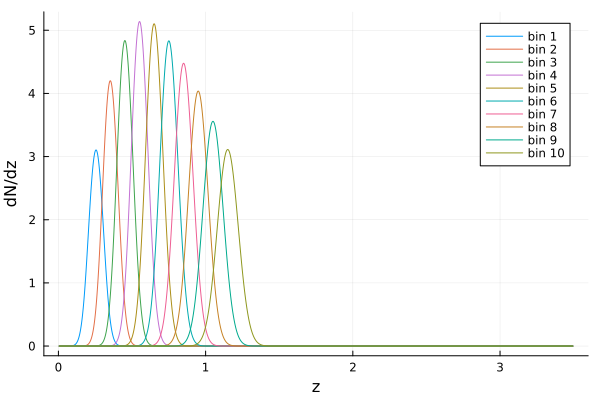

In [34]:
p = plot()
bin = size(n_z_matrix, 2)
for i in 1:bin
    plot!(p, z_n5k, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing n(z)

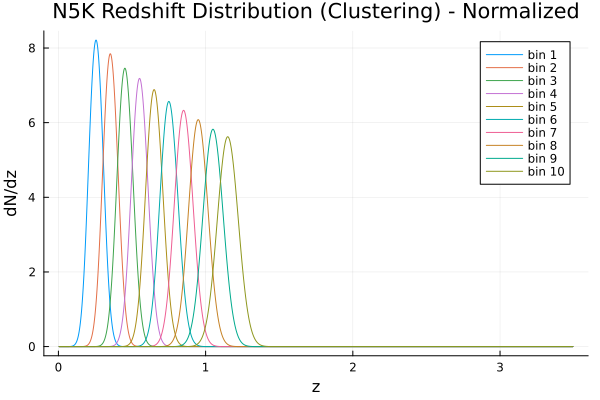

In [35]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:bin]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "N5K dN/dz normalization\n")
    write(f, "The N5K dN/dz values for each bin are normalized such that the integral over redshift is 1.\n")
    write(f, "The norms used for normalization are: \n$(norms)\n")
    write(f, "------------------------ \n")
    write(f, "The normalized N5K dN/dz values for each bin have dimensions: \n$(size(n_z_norm))\n")
    write(f, "MIN = $(minimum(n_z_norm)) || MAX = $(maximum(n_z_norm)) \n")
end;

#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

### Creating redshift array and comoving distance array for N5K data

In [36]:
### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = chi_of_z.(z_array); # array of comoving distances corresponding to z_range

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT ARRAY\n")
    write(f, "Redshift z_array is a vector or dimension: $(size(z_array))\n")
    write(f, "MIN = $(minimum(z_array)) || MAX = $(maximum(z_array))\n")
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCE ARRAY\n")
    write(f, "Comoving distance chi_array is a vector or dimension: $(size(chi_array))\n")
    write(f, "MIN = $(minimum(chi_array)) || MAX = $(maximum(chi_array))\n")
    write(f, "------------------------ \n")
    write(f, "Values of normalized N5K dN/dz (clustering) for the first bin are: \n$(n_z_norm[:, 1])\n")
    write(f, "------------------------ \n")
end;

### Setting number of COMOVING DISTANCE POINTS

In [37]:
cosmo = Blast.FlatΛCDM()
n_chi = 50;                  # Number of comoving distance points

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS: $n_chi\n")
end;

### Defining redshift array and comoving distance array with our $\chi_{min}$ and $\chi_{max}$

In [38]:
# Array of comoving distances
x_array = LinRange(26, 7000, n_chi)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCES AND CORRESPONDING REDSHIFTS\n")
    write(f, "Array of comoving distances x_array has dimensions: $(size(x_array))\n")
    write(f, "MIN = $(minimum(x_array)) || MAX = $(maximum(x_array)) \n")
    write(f, "Array of redshifts z_range has dimensions: $(size(z_range))\n")
    write(f, "MIN = $(minimum(z_range)) || MAX = $(maximum(z_range)) \n")
    write(f, "------------------------ \n")
end;

### BIAS

In [39]:
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = zeros(size(z_range))
b_z_array = b_0 .* sqrt.(1 .+ z_range); # bias as a function of redshift

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

### GROWTH FACTOR

In [40]:
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

### PLOTTING BIAS $b(z)$, COMOVING DISTANCE $\chi(z)$, and GROWTH FACTOR $D(z)$

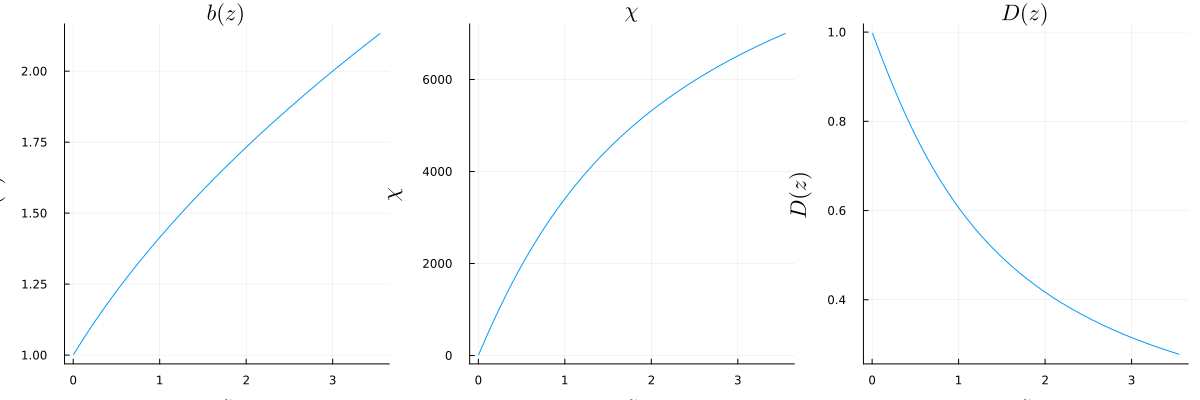

In [41]:
p1 = plot(z_range, 
          b_z_array, 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"$b(z)$", 
          title=L"$b(z)$")
p2 = plot(z_range, 
          x_array, 
          label=L"z and $\chi$",
          title = L"$\chi$",
          xlabel=L"$z$", 
          ylabel=L"$\chi$")
p3 = plot(z_range, 
          growth_array, 
          label="Growth Factor D(z)", 
          xlabel=L"$z$", 
          ylabel=L"$D(z)$", 
          title=L"$D(z)$")
plot(p1, p2, p3, layout=(1,3), titlefontsize=15, labelfontsize=15, legendfontsize=15, size=(1200,400), legend=false)

In [42]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Array of redshifts: z_range has dimensions: $(size(z_range)) || z_array has dimensions: $(size(z_array))\n")
  end;

### GETTING $n(z)$

In [43]:
n_bins = size(n_z_norm, 2) # number of tomographic bins
nz = zeros(n_chi, n_bins) # size nx per number of bins
for b in 1:n_bins
     nz_func = DataInterpolations.AkimaInterpolation(n_z_norm[:, b], z_array, extrapolation=ExtrapolationType.Linear)
     nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
     #println("Bin $b: Normalized n(z) integral: ", nz_norm)
     nz[:, b] = nz_func.(z_range)
     #println("Bin $b: n(z) has size: ", size(nz))
end

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
  end;

### GETTING the inverse of $H(z)$

In [44]:
#inv_Hz_array = [1.0 / Blast.compute_adimensional_hubble_factor(z, cosmo) for z in z_range];

In [45]:
prefac = x_array.^2 .* b_z_array .* growth_array
#kernel_composed = reshape(prefac, :, 1) .* nz .* inv_Hz_array;
kernel_composed = reshape(prefac, :, 1) .* nz;

In [46]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins n_bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
    write(f, "Size of prefactor array (chi^2 * b(z) * D(z)): $(size(prefac))\n")
    write(f, "Size of kernel_composed array: $(size(kernel_composed))\n")
    write(f, "The prefactor array is the product of chi^2, b(z), and D(z) evaluated at the redshifts corresponding to the comoving distances in x_array.\n")
    write(f, "Size of array z_range: $(size(z_range))\n")
    write(f, "Size of array x_array: $(size(x_array))\n")
    write(f, "Size of array b_z_array: $(size(b_z_array))\n")
    write(f, "Size of array growth_array: $(size(growth_array))\n")
    write(f, "Size of array nz: $(size(nz))\n")
  end;

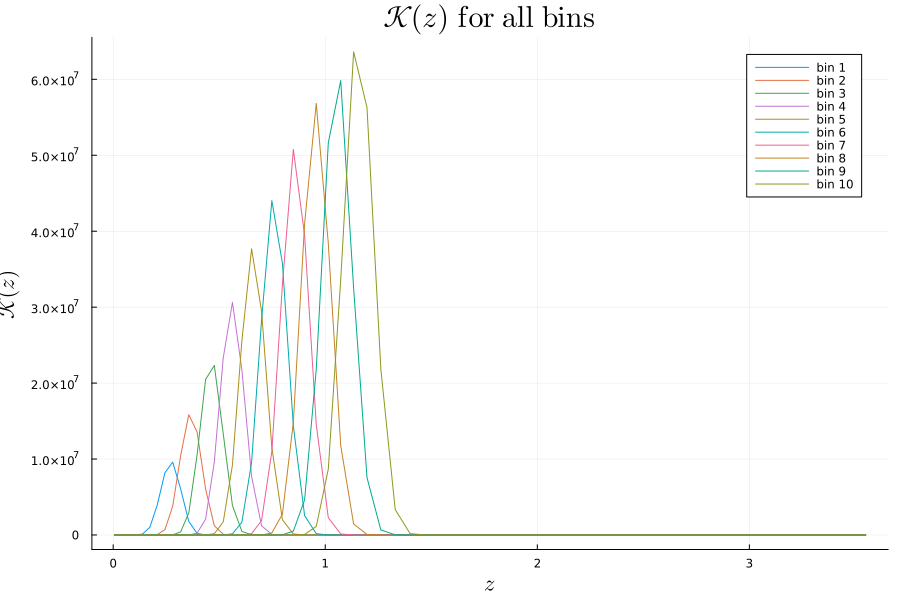

In [47]:
p = plot(
    xlabel=L"$z$",
    ylabel=L"\mathcal{K}(z)",
    title=L"\mathcal{K}(z)\ \mathrm{for\ all\ bins}",
    xlabelfontsize=15,
    ylabelfontsize=15,
    titlefontsize=20,
    legendfontsize=8,
    size=(900, 600)
)
for b in 1:size(kernel_composed, 2)
    plot!(p, z_range, kernel_composed[:, b], label="bin $b")
end
display(p)

In [48]:
ℓ = Blast.ℓ
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
chi = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
zed = z_of_χ.(chi)                                      # array of redshifts corresponding to the comoving distances
zmin = minimum(zed)                                     # minimum redshift
zmax = maximum(zed)                                     # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 500                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(15)+1;                                         # number of integration points

In [49]:
grid = Blast.setup_grid(zmin, zmax, N);

In [50]:
W_LL = zeros(length(ℓ), length(chi), length(chi), n_cheb + 1)
time_elapsed = @elapsed begin
    for i in eachindex(ℓ)
        W_LL[i, :, :, :] = Blast.compute_W̃(grid, ℓ[i], chi, zed, kmin, kmax; n_cheb=n_cheb)
        println("Computed W̃ for i = ", i)
    end
end
println("Computation of W̃ for all ℓ values took: ", time_elapsed, " seconds.")

Computed W̃ for i = 1
Computed W̃ for i = 2
Computed W̃ for i = 3
Computed W̃ for i = 4
Computed W̃ for i = 5
Computed W̃ for i = 6
Computed W̃ for i = 7
Computed W̃ for i = 8
Computed W̃ for i = 9
Computed W̃ for i = 10
Computed W̃ for i = 11
Computed W̃ for i = 12
Computed W̃ for i = 13
Computed W̃ for i = 14
Computed W̃ for i = 15
Computed W̃ for i = 16
Computed W̃ for i = 17
Computed W̃ for i = 18
Computed W̃ for i = 19
Computed W̃ for i = 20
Computed W̃ for i = 21
Computed W̃ for i = 22
Computation of W̃ for all ℓ values took: 2389.037759416 seconds.


In [51]:
# W_LL = zeros(length(ℓ), length(chi), length(chi), n_cheb + 1)
# time_elapsed = @elapsed begin
#     for i in eachindex(ℓ)
#         W_LL[i,:,:,:] = Blast.compute_W̃(ℓ[i], chi, zed, kmin, kmax, zmin, zmax; n_cheb, N)
#         println("Computed W̃ for i = ", i)
#     end
# end
# println("Computation of W̃ for all ℓ values took: ", time_elapsed, " seconds.")

In [52]:
# #i want to save in a file all W_LL_A and W_LL_B values for all ℓ, chi and chi' in a .npy file. i can use the NPZ package to do this.
# npzwrite("W_LL_A.npy", W_LL_A)
# npzwrite("W_LL_B.npy", W_LL_B)
# I now want to upload them
# W_LL_A = npzread("W_LL_A.npy")
# W_LL_B = npzread("W_LL_B.npy");

In [53]:
W_LL_A = W_LL
W_LL_B = W_LL
println("Size of W_LL_A: ", size(W_LL_A))
println("Size of W_LL_B: ", size(W_LL_B))

Size of W_LL_A: (22, 50, 50, 501)
Size of W_LL_B: (22, 50, 50, 501)


In [54]:
# chi_interp = chi_of_z
# b_func = DataInterpolations.AkimaInterpolation(b_z_array, z_range, extrapolation=ExtrapolationType.Linear)
# D_func = DataInterpolations.AkimaInterpolation(growth_array, z_range, extrapolation=ExtrapolationType.Linear)
# #invH_func = DataInterpolations.AkimaInterpolation(inv_Hz_array, z_range, extrapolation=ExtrapolationType.Linear)

# n_funcs = Vector{Any}(undef, n_bins)
# for b in 1:n_bins
#     n_funcs[b] = DataInterpolations.AkimaInterpolation(nz[:, b], z_range, extrapolation=ExtrapolationType.Linear)
# end

# cheb_coeffs_all_bins = zeros(n_cheb + 1, n_bins)
# for i in 1:n_bins
#     cheb_coeffs_all_bins[:, i] = Blast.compute_W̃_chebcoeffs(
#         chi_interp,
#         n_funcs[i],    
#         b_func,
#         D_func,
#         #invH_func,
#         zmin,
#         zmax;
#         n_cheb=n_cheb,
#         N=N
#     )
#     println("Chebyshev coefficients for bin ", i)
# end
# assicurati che `grid` sia stato creato prima (vedi cella con Blast.setup_grid)
# grid = Blast.setup_grid(zmin, zmax, N)

chi_interp = chi_of_z
b_func = DataInterpolations.AkimaInterpolation(b_z_array, z_range, extrapolation=ExtrapolationType.Linear)
D_func = DataInterpolations.AkimaInterpolation(growth_array, z_range, extrapolation=ExtrapolationType.Linear)
#invH_func = DataInterpolations.AkimaInterpolation(inv_Hz_array, z_range, extrapolation=ExtrapolationType.Linear)

n_funcs = Vector{Any}(undef, n_bins)
for b in 1:n_bins
    n_funcs[b] = DataInterpolations.AkimaInterpolation(nz[:, b], z_range, extrapolation=ExtrapolationType.Linear)
end

cheb_coeffs_all_bins = zeros(n_cheb + 1, n_bins)
for i in 1:n_bins
        cheb_coeffs_all_bins[:, i] = Blast.compute_W̃_chebcoeffs(grid, chi_interp, n_funcs[i], b_func, D_func; n_cheb=n_cheb)           
end
println("Chebyshev coefficients computed for all bins.")

Chebyshev coefficients computed for all bins.


In [55]:
println("Size of cheb_coeffs_all_bins: ", size(cheb_coeffs_all_bins))

Size of cheb_coeffs_all_bins: (501, 10)


In [56]:
# W_LL_A ha dimensioni [nℓ, n_chi, n_chi, n_cheb+1]
# cheb_coeff_A è [n_cheb+1]  (indipendente da ℓ, k, k1 !)
cheb_coeff_A = cheb_coeffs_all_bins[:, 1] # prendiamo i coefficienti di Chebyshev per il primo bin
cheb_coeff_B = cheb_coeffs_all_bins[:, 10] 
@tullio I_A[l,nchi, nchi'] := cheb_coeff_A[ncheb] * W_LL_A[l, nchi, nchi', ncheb];
@tullio I_B[l,nchi, nchi'] := cheb_coeff_B[ncheb] * W_LL_B[l, nchi, nchi', ncheb];

In [57]:
println("Size of I_A: ", size(I_A))
println("Size of I_B: ", size(I_B))

Size of I_A: (22, 50, 50)
Size of I_B: (22, 50, 50)


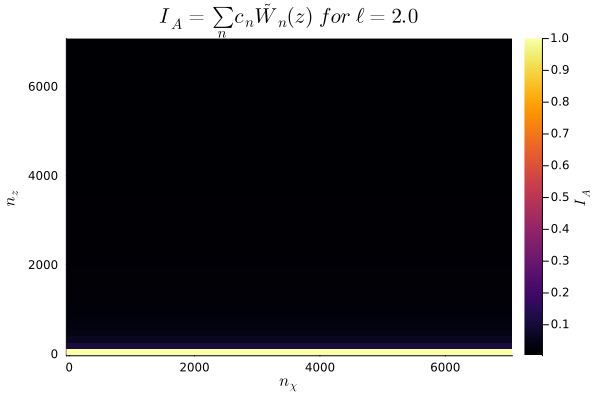

In [68]:
#i want a heatmap of I_A for a fixed ℓ value, as a function of chi and chi'. i can use the Plots package to do this.
nl_index = 10 # index for the ℓ value to plot
heatmap(
    chi, chi, I_A[nl_index, :, :]/maximum(I_A[nl_index, :, :]),
    xlabel = L"n_{\chi}",
    ylabel = L"n_{z}",
    title = L"I_A = \sum_n c_n \tilde{W}_n(z) \ for \ \ell = 2.0",
    colorbar_title = L"I_A"
)

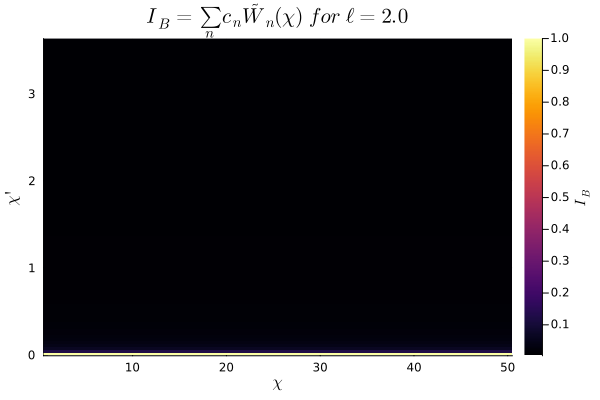

In [60]:
#i want a heatmap of I_B for a fixed ℓ value, as a function of chi. i can use the Plots package to do this.
nl_index = 2 # index for the ℓ value to plot
heatmap(
    1:n_chi, zed, I_B[nl_index, :, :]/maximum(I_B[nl_index, :, :]),
    xlabel = L"\chi",
    ylabel = L"\chi'",
    title = L"I_B = \sum_n c_n \tilde{W}_n(\chi) \ for \ \ell = 2.0",
    colorbar_title = L"I_B"
)

## Now the Power Spectrum

In [ ]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

println("Dimension of k points: ", size(k)[1])
println("Dimension of Pklin: ", size(Pklin)[1])
println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)

In [ ]:
# Recuperiamo la griglia di k geometrici (lunga 96) usata a monte per generare I_A e I_B
k_geometrico = Blast.get_clencurt_grid(kmin, kmax, n_chi) 
nk_geo = length(k_geometrico) # 96

In [ ]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
ll_reshaped = zeros(dtype, length(ell), 5, 5)
gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1
for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [ ]:
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_linear_full.npy"))
Cℓ_CL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_linear_full.npy"))
Cℓ_LL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_linear_full.npy"))
Cℓ_CC_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_nl_full.npy"))
Cℓ_CL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_nl_full.npy"))
Cℓ_LL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_nl_full.npy"));

In [ ]:
clustering_Cℓ 
final_clustering_Cℓ = clustering_Cℓ + Cℓ_CC_limb_nl - Cℓ_CC_limb
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber+200_full.npy"))
total_Cℓ_CC = cat(final_clustering_Cℓ, Cℓ_CC_limb, dims=1)

In [ ]:
# Interpolating to go on the same n5k grid
elle = dtype.(reverse(chebpoints(100, 2, 2000)))
ℓ_min = 2
ℓ_max = 2000

interp_Cℓ_CC = zeros(dtype, length(ell), 10, 10)

for i in 1:10
    for j in i:10
        interpol = chebinterp(reverse(total_Cℓ_CC[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CC[:,i,j] = interpol.(ell) ./ (ell.*ell)
        interp_Cℓ_CC[:,j,i] = interp_Cℓ_CC[:,i,j]
    end
end

In [ ]:
# i = 10
# j = 10
# nl = 65 #set this to 103 to see up to ℓ=2000.
# plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j], label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
#     xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
# plot!(ell[1:nl], gg_reshaped[1:nl,i,j], label = "N5K")

In [ ]:
k_geom = Blast.get_clencurt_grid(kmin, kmax, n_chi)
nk_geom = length(k_geom) # Sarà esattamente 96
w_k_geom = Blast.simpson_weight_array(nk_geom)
Δk_geom = (last(k_geom) - first(k_geom)) / (nk_geom - 1)
normalization = 2 / pi

# 2. Costruiamo Pk_3D valutando il Power Spectrum nei punti esatti della griglia geometrica k
Pk_3D_96 = zeros(length(chi), length(chi), nk_geom)
for m in 1:nk_geom
    for i in eachindex(chi)
        for j in eachindex(chi)
            # power_spectrum_nl accetta qualsiasi valore continuo di k, quindi legge k_geom[m] perfettamente
            Pk_3D_96[i, j, m] = power_spectrum_nl(k_geom[m], chi[i], chi[j])
        end
    end
end

# 3. Prepariamo il peso dell'integrale coerente con la griglia geometrica
integrand_k_weight_96 = @. normalization * k_geom^2 * w_k_geom * Δk_geom

# 4. Contrazione Tensoriale Totale (Tutti gli indici 'm' ora concordano a 96)
@tullio S_ell_nativo[li, ik1, ik2] := integrand_k_weight_96[m] * Pk_3D_96[ik1, ik2, m] * I_A[li, ik1, m] * I_B[li, ik2, m];

# 5. Estrazione della diagonale dello spettro sulla griglia nativa di multipoli (elle_nativo)
# Nota: Assicurati che l'asse 'li' corrisponda alla griglia dei punti di Chebyshev usata a monte (es. 100 punti)
n_ell_nativo = size(S_ell_nativo, 1)
Cl_nativo_bin1 = zeros(n_ell_nativo)

for li in 1:n_ell_nativo
    for ik in 1:size(S_ell_nativo, 2)
        Cl_nativo_bin1[li] += S_ell_nativo[li, ik, ik]
    end
end

# Applichiamo il fattore globale di calibrazione trovato nel turno precedente
CALIBRATION_FACTOR = 5.224962087604823e-22
#CALIBRATION_FACTOR = 1.0 # Sostituisci con il fattore di calibrazione corretto
Cl_nativo_bin1 .*= CALIBRATION_FACTOR;

In [ ]:
plot(ell[1:nl_plot], gg_reshaped[1:nl_plot, 1, 1], label="N5K_GG")
plot!(ell[1:nl_plot], Cl_final_interpolato[1:nl_plot], label="beyond_BlAST")

In [ ]:
# fattore_di_scala = gg_reshaped[1, 1, 1] / C_[1]
# println("Moltiplica il tuo S_ell_esatto per: ", fattore_di_scala)